In [4]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import pearsonr
import cmocean
import imdlib as imd

In [7]:
def preprocess_data(imd_ds, imerg_ds):
    """
    Aligns IMD and IMERG datasets in time and space for comparison.
    
    - Finds common time period.
    - Filters for Southwest Monsoon season (June-September).
    - Clips and regrids IMERG to match IMD's grid.
    - Applies a common NaN mask based on IMD's land data.
    """
    print("Starting data preprocessing...")
    
    # --- Temporal Alignment ---
    # Find common time range
    common_time_start = max(imd_ds.time.min().values, imerg_ds.time.min().values)
    common_time_end = min(imd_ds.time.max().values, imerg_ds.time.max().values)
    
    imd_ds = imd_ds.sel(time=slice(common_time_start, common_time_end))
    imerg_ds = imerg_ds.sel(time=slice(common_time_start, common_time_end))
    
    # Filter for monsoon months (June, July, August, September)
    is_monsoon = imd_ds.time.dt.month.isin([6, 7, 8, 9])
    imd_ds = imd_ds.sel(time=is_monsoon)
    imerg_ds = imerg_ds.sel(time=is_monsoon)
    
    print(f"Data filtered for monsoon season (JJAS) between {pd.to_datetime(str(common_time_start)).year} and {pd.to_datetime(str(common_time_end)).year}.")

    # --- Spatial Alignment ---
    # Get IMD grid definition
    target_lats = imd_ds['lat']
    target_lons = imd_ds['lon']
    
    # Clip IMERG to IMD's spatial extent for efficiency
    imerg_ds_clipped = imerg_ds.sel(
        lat=slice(target_lats.max(), target_lats.min()),
        lon=slice(target_lons.min(), target_lons.max())
    )
    
    # Regrid IMERG to IMD's resolution using bilinear interpolation
    print("Regridding IMERG data to match IMD resolution (0.25 deg)...")
    imerg_regridded = imerg_ds_clipped.interp(
        lat=target_lats, lon=target_lons, method="linear"
    )

    # --- Masking ---
    # Create a mask where IMD has valid (non-NaN) data.
    # We use a time-invariant mask by checking for any valid data point along the time axis.
    valid_mask = imd_ds['rain'].notnull().any(dim='time')
    
    # Apply the mask to both datasets. This ensures all calculations
    # are performed only on the valid Indian landmass grid cells.
    imd_processed = imd_ds.where(valid_mask)
    imerg_processed = imerg_regridded.where(valid_mask)

    print("Preprocessing complete. Datasets are aligned and masked.")
    return imd_processed, imerg_processed

# --- 3. ANALYSIS AND PLOTTING FUNCTIONS ---

def plot_mean_seasonal_rainfall(imd_ds, imerg_ds):
    """Calculates and plots the mean monsoon rainfall, replicating Figure 2."""
    print("Generating Mean Seasonal Rainfall maps (Figure 2)...")
    
    # Calculate mean daily rainfall for the entire period
    imd_mean = imd_ds['rain'].mean(dim='time')
    imerg_mean = imerg_ds['precipitation'].mean(dim='time')
    
    fig = plt.figure(figsize=(16, 7))
    fig.suptitle('Mean Daily Monsoon (JJAS) Rainfall (mm/day)', fontsize=16, y=0.98)
    
    # Find common data range for consistent colorbar
    vmin = min(imd_mean.min(), imerg_mean.min())
    vmax = max(imd_mean.max(), imerg_mean.max())
    
    # Plot IMD data
    ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
    imd_mean.plot(ax=ax1, cmap=cmocean.cm.rain, vmin=vmin, vmax=vmax,
                  cbar_kwargs={'label': 'Rainfall (mm/day)'})
    ax1.coastlines()
    ax1.add_feature(cfeature.BORDERS, linestyle=':')
    ax1.set_title('IMD Gridded Data')
    
    # Plot IMERG data
    ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree())
    imerg_mean.plot(ax=ax2, cmap=cmocean.cm.rain, vmin=vmin, vmax=vmax,
                    cbar_kwargs={'label': 'Rainfall (mm/day)'})
    ax2.coastlines()
    ax2.add_feature(cfeature.BORDERS, linestyle=':')
    ax2.set_title('IMERG Regridded Data')
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

def calculate_skill_metrics(imd_ds, imerg_ds, threshold=0.5):
    """Calculates and displays categorical skill metrics, replicating Table 3."""
    print(f"Calculating Skill Metrics (Table 3) using rain/no-rain threshold of {threshold} mm/day...")
    
    results = []
    years = np.unique(imd_ds.time.dt.year)
    
    for year in years:
        imd_year = imd_ds.sel(time=imd_ds.time.dt.year == year)
        imerg_year = imerg_ds.sel(time=imerg_ds.time.dt.year == year)
        
        # Boolean arrays for rain event detection
        imd_rain = imd_year['rain'] > threshold
        imerg_rain = imerg_year['precipitation'] > threshold
        
        # Calculate contingency table elements
        hits = (imerg_rain & imd_rain).sum().item()
        misses = (~imerg_rain & imd_rain).sum().item()
        false_alarms = (imerg_rain & ~imd_rain).sum().item()
        correct_negatives = (~imerg_rain & ~imd_rain).sum().item()

        # Calculate metrics (avoiding division by zero)
        pod = hits / (hits + misses) if (hits + misses) > 0 else 0
        far = false_alarms / (hits + false_alarms) if (hits + false_alarms) > 0 else 0
        fbi = (hits + false_alarms) / (hits + misses) if (hits + misses) > 0 else 0
        pss = (hits * correct_negatives - false_alarms * misses) / \
              ((hits + misses) * (false_alarms + correct_negatives)) if \
              (hits + misses > 0) and (false_alarms + correct_negatives > 0) else 0

        results.append({'Year': year, 'POD': pod, 'FAR': far, 'FBI': fbi, 'PSS': pss})

    df = pd.DataFrame(results)
    print("\n--- Categorical Skill Metrics ---")
    print(df.to_string(index=False, float_format="%.2f"))
    return df
    
def plot_spatial_error_metrics(imd_ds, imerg_ds):
    """Calculates and plots spatial maps of error metrics, replicating Figure 4."""
    print("Generating Spatial Error Metric maps (Figure 4)...")
    
    # --- Calculations ---
    imd_data = imd_ds['rain']
    imerg_data = imerg_ds['precipitation']
    
    # Bias
    bias = imerg_data.mean(dim='time') - imd_data.mean(dim='time')
    
    # RMSE
    rmse = np.sqrt(((imerg_data - imd_data)**2).mean(dim='time'))
    
    # Correlation (using apply_ufunc for pixel-wise calculation)
    def calculate_correlation(x, y):
        # Drop NaNs for this specific pixel's timeseries
        valid_indices = ~np.isnan(x) & ~np.isnan(y)
        x_valid, y_valid = x[valid_indices], y[valid_indices]
        if len(x_valid) < 2: # Need at least 2 points to correlate
            return np.nan
        return pearsonr(x_valid, y_valid)[0]

    correlation = xr.apply_ufunc(
        calculate_correlation, imd_data, imerg_data,
        input_core_dims=[['time'], ['time']],
        dask="parallelized", # Use dask for potential speedup
        output_dtypes=[float]
    )
    correlation.name = "Correlation"
    
    # Coefficient of Variation (CV)
    cv_imd = imd_data.std(dim='time') / imd_data.mean(dim='time')
    cv_imerg = imerg_data.std(dim='time') / imerg_data.mean(dim='time')

    # --- Plotting ---
    fig = plt.figure(figsize=(14, 18))
    gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.1)
    fig.suptitle('Spatial Distribution of Error Metrics', fontsize=18, y=0.95)

    def create_map_subplot(fig, spec, data, title, cmap, cbar_label):
        ax = fig.add_subplot(spec, projection=ccrs.PlateCarree())
        data.plot(ax=ax, cmap=cmap, cbar_kwargs={'label': cbar_label, 'orientation': 'horizontal', 'pad': 0.1})
        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linestyle=':')
        ax.set_title(title, fontsize=14)
        return ax

    create_map_subplot(fig, gs[0, 0], bias, 'Bias (IMERG - IMD)', cmocean.cm.balance, 'Bias (mm/day)')
    create_map_subplot(fig, gs[0, 1], correlation, 'Temporal Correlation', cmocean.cm.amp, 'Pearson r')
    create_map_subplot(fig, gs[1, 0], rmse, 'Root Mean Square Error (RMSE)', cmocean.cm.amp, 'RMSE (mm/day)')
    create_map_subplot(fig, gs[1, 1], cv_imd, 'CV of IMD Rainfall', cmocean.cm.haline, 'CV (unitless)')
    create_map_subplot(fig, gs[2, 0], cv_imerg, 'CV of IMERG Rainfall', cmocean.cm.haline, 'CV (unitless)')
    
    # Remove the last empty subplot
    fig.delaxes(fig.axes[-1])

    plt.show()

def plot_rainfall_category_scatters(imd_ds, imerg_ds):
    """Creates scatter plots for different rainfall categories, replicating Figure 7."""
    print("Generating Rainfall Category Scatter plots (Figure 7)...")

    # Define rainfall categories as per the paper
    # Bins: (0.5, 2.5], (2.5, 15.6], (15.6, 64.5], (64.5, 115.6], (115.6, 204.5], [204.5, inf)
    categories = {
        'R1: Very Light (0.5-2.5)': (0.5, 2.5),
        'R2: Light (2.5-15.6)': (2.5, 15.6),
        'R3: Moderate (15.6-64.5)': (15.6, 64.5),
        'R4: Heavy (64.5-115.6)': (64.5, 115.6),
        'R5: Very Heavy (115.6-204.5)': (115.6, 204.5),
        'R6: Extremely Heavy (>204.5)': (204.5, np.inf),
    }

    imd_data = imd_ds['rain']
    imerg_data = imerg_ds['precipitation']

    fig, axes = plt.subplots(2, 6, figsize=(20, 8), sharey='row', sharex='row')
    fig.suptitle('Comparison of Rainfall Categories (IMERG vs IMD)', fontsize=16, y=1.02)
    axes[0, 0].set_ylabel('Number of Grids (IMERG)', fontsize=12)
    axes[1, 0].set_ylabel('Total Rainfall in Grids (mm) (IMERG)', fontsize=12)

    for i, (cat_name, (lower, upper)) in enumerate(categories.items()):
        ax_grid_count = axes[0, i]
        ax_rain_sum = axes[1, i]

        # --- 7a: Number of Grids ---
        imd_cat_mask = (imd_data > lower) & (imd_data <= upper)
        imerg_cat_mask = (imerg_data > lower) & (imerg_data <= upper)
        
        imd_grid_counts = imd_cat_mask.sum(dim=['lat', 'lon'])
        imerg_grid_counts = imerg_cat_mask.sum(dim=['lat', 'lon'])

        # Filter out days where both counts are zero
        valid_days = (imd_grid_counts > 0) | (imerg_grid_counts > 0)
        
        # Plotting
        ax_grid_count.scatter(imd_grid_counts.where(valid_days, drop=True),
                              imerg_grid_counts.where(valid_days, drop=True),
                              alpha=0.5, s=10)
        corr_grid, _ = pearsonr(imd_grid_counts.where(valid_days), imerg_grid_counts.where(valid_days))
        ax_grid_count.set_title(f"{cat_name}\nR={corr_grid:.2f}", fontsize=10)

        # --- 7b: Rainfall Amount ---
        # For each day, find grids in the category based on IMD
        # Then sum rainfall in those specific grids for both IMD and IMERG
        daily_imd_sum = []
        daily_imerg_sum = []
        
        for t in imd_data.time:
            imd_daily = imd_data.sel(time=t)
            imerg_daily = imerg_data.sel(time=t)
            
            # Mask based on IMD's daily data
            mask_daily = (imd_daily > lower) & (imd_daily <= upper)
            
            if mask_daily.any():
                daily_imd_sum.append(imd_daily.where(mask_daily).sum().item())
                daily_imerg_sum.append(imerg_daily.where(mask_daily).sum().item())
        
        if daily_imd_sum:
            ax_rain_sum.scatter(daily_imd_sum, daily_imerg_sum, alpha=0.5, s=10, color='g')
            corr_sum, _ = pearsonr(daily_imd_sum, daily_imerg_sum)
            ax_rain_sum.text(0.05, 0.95, f'R={corr_sum:.2f}', transform=ax_rain_sum.transAxes,
                             fontsize=10, verticalalignment='top')
        
        ax_rain_sum.set_xlabel('IMD', fontsize=10)
        if i > 0:
            ax_rain_sum.tick_params(labelleft=False)
            ax_grid_count.tick_params(labelleft=False)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    fig.text(0.5, -0.01, 'Daily Grid Count / Total Rainfall (IMD)', ha='center', fontsize=12)
    plt.show()

In [5]:
imerg_combined = xr.open_dataset("/Datastorage/saptarishi.dhanuka_asp25/imerg_data/combined_imerg_20150701_20240929.nc4")
start_yr = 2015
end_yr = 2024
variable = 'rain' # other options are ('tmin'/ 'tmax')
file_dir = "/Datastorage/saptarishi.dhanuka_asp25/imdlib_data/raw_imdlib"
data = imd.open_data(variable, start_yr, end_yr, 'yearwise', file_dir+'/rain/')
ds = data.get_xarray()
ds

<xarray.Dataset> Size: 509MB
Dimensions:  (time: 3653, lat: 129, lon: 135)
Coordinates:
  * lat      (lat) float64 1kB 6.5 6.75 7.0 7.25 7.5 ... 37.75 38.0 38.25 38.5
  * lon      (lon) float64 1kB 66.5 66.75 67.0 67.25 ... 99.25 99.5 99.75 100.0
  * time     (time) datetime64[ns] 29kB 2015-01-01 2015-01-02 ... 2024-12-31
Data variables:
    rain     (time, lat, lon) float64 509MB -999.0 -999.0 ... -999.0 -999.0
Attributes:
    Conventions:  CF-1.7
    title:        IMD gridded data
    source:       https://imdpune.gov.in/
    history:      2025-06-20 14:44:42.370868 Python
    references:   
    comment:      
    crs:          epsg:4326

In [6]:
imd_ds = ds.where(ds ['rain'] != -999.)

In [15]:
# Load data - use the dummy data generator for this example.
# To use real data, comment this line and load your netCDF files, e.g.:
# imd_dataset = xr.open_dataset("path/to/your/imd_file.nc")
# imerg_dataset = xr.open_dataset("path/to/your/imerg_file.nc")
imd_dataset, imerg_dataset = imd_ds, imerg_combined

print("Starting Preprocessing: Temporal Alignment and Monsoon Filtering...")

# Find the common time range between the two datasets
common_time_start = max(imd_dataset.time.min().values, imerg_dataset.time.min().values)
common_time_end = min(imd_dataset.time.max().values, imerg_dataset.time.max().values)

# Select the common time period for both datasets
imd_ds_common_time = imd_dataset.sel(time=slice(common_time_start, common_time_end))
imerg_ds_common_time = imerg_dataset.sel(time=slice(common_time_start, common_time_end))

print(f"Common time range found: {pd.to_datetime(str(common_time_start)).date()} to {pd.to_datetime(str(common_time_end)).date()}")

# --- FIX APPLIED HERE ---
# Filter IMD for monsoon months (June, July, August, September)
is_monsoon_imd = imd_ds_common_time.time.dt.month.isin([6, 7, 8, 9])
imd_monsoon = imd_ds_common_time.sel(time=is_monsoon_imd)

# Filter IMERG for monsoon months using ITS OWN time coordinate
is_monsoon_imerg = imerg_ds_common_time.time.dt.month.isin([6, 7, 8, 9])
imerg_monsoon = imerg_ds_common_time.sel(time=is_monsoon_imerg)

print(f"Filtered IMD for monsoon. New time steps: {len(imd_monsoon.time)}")
print(f"Filtered IMERG for monsoon. New time steps: {len(imerg_monsoon.time)}")

display(imd_monsoon)

Starting Preprocessing: Temporal Alignment and Monsoon Filtering...
Common time range found: 2015-07-01 to 2024-09-27
Filtered IMD for monsoon. New time steps: 1187
Filtered IMERG for monsoon. New time steps: 1186


<xarray.Dataset> Size: 165MB
Dimensions:  (time: 1187, lat: 129, lon: 135)
Coordinates:
  * lat      (lat) float64 1kB 6.5 6.75 7.0 7.25 7.5 ... 37.75 38.0 38.25 38.5
  * lon      (lon) float64 1kB 66.5 66.75 67.0 67.25 ... 99.25 99.5 99.75 100.0
  * time     (time) datetime64[ns] 9kB 2015-07-01 2015-07-02 ... 2024-09-27
Data variables:
    rain     (time, lat, lon) float64 165MB nan nan nan nan ... nan nan nan nan
Attributes:
    Conventions:  CF-1.7
    title:        IMD gridded data
    source:       https://imdpune.gov.in/
    history:      2025-06-20 14:44:42.370868 Python
    references:   
    comment:      
    crs:          epsg:4326

In [16]:
print("Starting Preprocessing: Spatial Alignment...")

# Get the target grid definition from the IMD dataset
target_lats = imd_monsoon['lat']
target_lons = imd_monsoon['lon']

# For efficiency, first clip the IMERG data to the spatial bounds of the IMD data
imerg_clipped = imerg_monsoon.sel(
    lat=slice(target_lats.max(), target_lats.min()), # lat is decreasing in IMERG
    lon=slice(target_lons.min(), target_lons.max())
)

# Regrid the clipped IMERG data to match IMD's resolution using linear interpolation
print("Regridding IMERG data to match IMD resolution (0.25 deg)...")
imerg_regridded = imerg_clipped.interp(
    lat=target_lats, lon=target_lons, method="linear"
)

print("IMERG data has been regridded.")
display(imerg_regridded)

Starting Preprocessing: Spatial Alignment...
Regridding IMERG data to match IMD resolution (0.25 deg)...
IMERG data has been regridded.


<xarray.Dataset> Size: 330MB
Dimensions:        (time: 1186, lon: 135, lat: 129)
Coordinates:
  * time           (time) datetime64[ns] 9kB 2015-07-01 ... 2024-09-27
  * lat            (lat) float64 1kB 6.5 6.75 7.0 7.25 ... 37.75 38.0 38.25 38.5
  * lon            (lon) float64 1kB 66.5 66.75 67.0 67.25 ... 99.5 99.75 100.0
Data variables:
    precipitation  (time, lon, lat) float64 165MB nan nan nan ... 0.5875 nan nan
    randomError    (time, lon, lat) float64 165MB nan nan nan ... 53.62 nan nan
Attributes:
    BeginDate:       2015-07-01
    BeginTime:       00:00:00.000Z
    EndDate:         2015-07-01
    EndTime:         23:59:59.999Z
    FileHeader:      StartGranuleDateTime=2015-07-01T00:00:00.000Z;\nStopGran...
    InputPointer:    3B-HHR.MS.MRG.3IMERG.20150701-S000000-E002959.0000.V07B....
    title:           GPM IMERG Final Precipitation L3 1 day 0.1 degree x 0.1 ...
    DOI:             10.5067/GPM/IMERGDF/DAY/07
    ProductionTime:  2023-12-18T15:32:13.665Z

In [17]:
print("Starting Preprocessing: Applying Land Mask...")

# Create a mask based on where IMD has valid (non-NaN) data.
# We check for any valid data point along the time dimension to create a static land mask.
valid_land_mask = imd_monsoon['rain'].notnull().any(dim='time')

# Apply this mask to both datasets. This sets all ocean/non-data grid cells to NaN.
imd_proc = imd_monsoon.where(valid_land_mask)
imerg_proc = imerg_regridded.where(valid_land_mask)

print("Preprocessing complete. Datasets are now aligned and masked.")
print("\n--- Final Processed IMD Dataset ---")
display(imd_proc)
print("\n--- Final Processed IMERG Dataset ---")
display(imerg_proc)

Starting Preprocessing: Applying Land Mask...
Preprocessing complete. Datasets are now aligned and masked.

--- Final Processed IMD Dataset ---


<xarray.Dataset> Size: 165MB
Dimensions:  (time: 1187, lat: 129, lon: 135)
Coordinates:
  * lat      (lat) float64 1kB 6.5 6.75 7.0 7.25 7.5 ... 37.75 38.0 38.25 38.5
  * lon      (lon) float64 1kB 66.5 66.75 67.0 67.25 ... 99.25 99.5 99.75 100.0
  * time     (time) datetime64[ns] 9kB 2015-07-01 2015-07-02 ... 2024-09-27
Data variables:
    rain     (time, lat, lon) float64 165MB nan nan nan nan ... nan nan nan nan
Attributes:
    Conventions:  CF-1.7
    title:        IMD gridded data
    source:       https://imdpune.gov.in/
    history:      2025-06-20 14:44:42.370868 Python
    references:   
    comment:      
    crs:          epsg:4326


--- Final Processed IMERG Dataset ---


<xarray.Dataset> Size: 330MB
Dimensions:        (time: 1186, lon: 135, lat: 129)
Coordinates:
  * time           (time) datetime64[ns] 9kB 2015-07-01 ... 2024-09-27
  * lat            (lat) float64 1kB 6.5 6.75 7.0 7.25 ... 37.75 38.0 38.25 38.5
  * lon            (lon) float64 1kB 66.5 66.75 67.0 67.25 ... 99.5 99.75 100.0
Data variables:
    precipitation  (time, lon, lat) float64 165MB nan nan nan ... nan nan nan
    randomError    (time, lon, lat) float64 165MB nan nan nan ... nan nan nan
Attributes:
    BeginDate:       2015-07-01
    BeginTime:       00:00:00.000Z
    EndDate:         2015-07-01
    EndTime:         23:59:59.999Z
    FileHeader:      StartGranuleDateTime=2015-07-01T00:00:00.000Z;\nStopGran...
    InputPointer:    3B-HHR.MS.MRG.3IMERG.20150701-S000000-E002959.0000.V07B....
    title:           GPM IMERG Final Precipitation L3 1 day 0.1 degree x 0.1 ...
    DOI:             10.5067/GPM/IMERGDF/DAY/07
    ProductionTime:  2023-12-18T15:32:13.665Z

Generating Mean Seasonal Rainfall maps (Figure 2)...


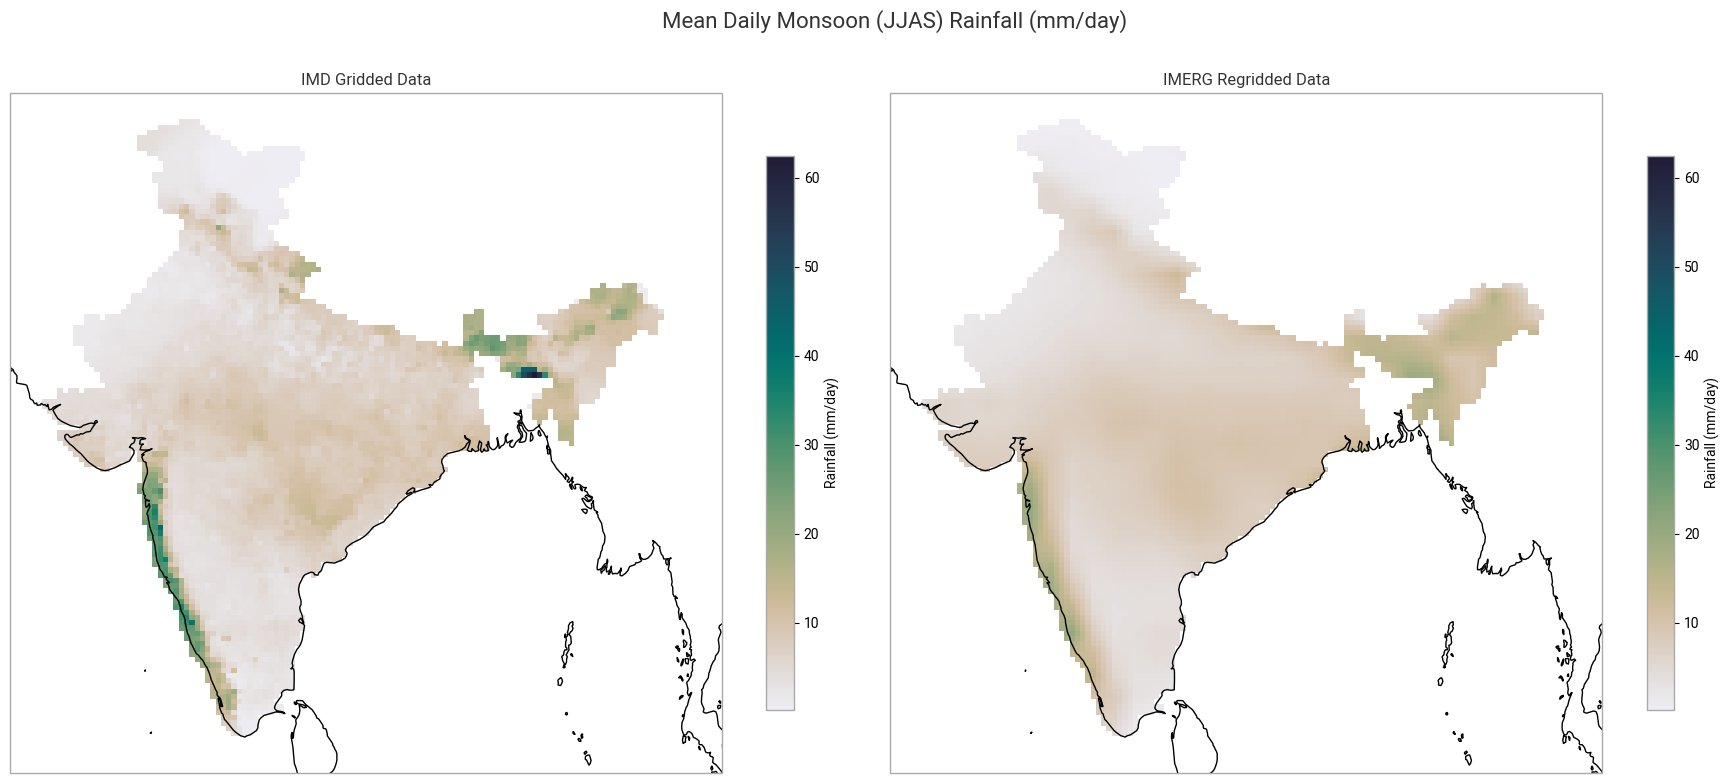

In [41]:
print("Generating Mean Seasonal Rainfall maps (Figure 2)...")

# Calculate the mean daily rainfall over the entire monsoon period
imd_mean_seasonal = imd_proc['rain'].mean(dim='time')
imerg_mean_seasonal = imerg_proc['precipitation'].mean(dim='time')

fig = plt.figure(figsize=(18, 8))
fig.suptitle('Mean Daily Monsoon (JJAS) Rainfall (mm/day)', fontsize=16, y=0.98)

# Find a common data range for a consistent colorbar
vmin = min(imd_mean_seasonal.min(), imerg_mean_seasonal.min())
vmax = max(imd_mean_seasonal.max(), imerg_mean_seasonal.max())

# Plot IMD data
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
imd_mean_seasonal.plot(ax=ax1, cmap=cmocean.cm.rain, vmin=vmin, vmax=vmax,
                       cbar_kwargs={'label': 'Rainfall (mm/day)', 'shrink': 0.8})
ax1.coastlines()
# ax1.add_feature(cfeature.BORDERS, linestyle=':')
ax1.set_title('IMD Gridded Data')
# ax1.gridlines(draw_labels=True, linestyle='--', alpha=0.5)

# Plot IMERG data
ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree())
imerg_mean_seasonal.transpose().plot(ax=ax2, cmap=cmocean.cm.rain, vmin=vmin, vmax=vmax,
                         cbar_kwargs={'label': 'Rainfall (mm/day)', 'shrink': 0.8})
ax2.coastlines()
# ax2.add_feature(cfeature.BORDERS, linestyle=':')
ax2.set_title('IMERG Regridded Data')
# ax2.gridlines(draw_labels=True, linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [43]:
# Replicate Table 3: Categorical skill metrics
skill_metrics_df = calculate_skill_metrics(imd_proc, imerg_proc)

Calculating Skill Metrics (Table 3) using rain/no-rain threshold of 0.5 mm/day...

--- Categorical Skill Metrics ---
 Year  POD  FAR  FBI  PSS
 2015 0.84 0.40 1.40 0.75
 2016 0.86 0.37 1.36 0.78
 2017 0.85 0.38 1.38 0.76
 2018 0.84 0.39 1.37 0.76
 2019 0.85 0.37 1.35 0.76
 2020 0.86 0.36 1.34 0.77
 2021 0.86 0.37 1.35 0.77
 2022 0.86 0.36 1.35 0.77
 2023 0.85 0.39 1.40 0.77
 2024 0.87 0.37 1.39 0.78


In [46]:
"""Calculates and plots spatial maps of error metrics, replicating Figure 4."""
print("Generating Spatial Error Metric maps (Figure 4)...")

# --- Calculations ---
imd_data = imd_proc['rain']
imerg_data = imerg_proc['precipitation']


Generating Spatial Error Metric maps (Figure 4)...


In [62]:
imerg_data = imerg_data.transpose()

In [61]:
imd_data

<xarray.DataArray 'rain' (time: 1186, lat: 129, lon: 135)> Size: 165MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], shape=(1186, 129, 135))
Coordinates:
  * lat      (lat) float64 1kB 6.5 6.75 7.0 7.25 7.5 ... 37.75 38.0 38.25 38.5
  * lon      (lon) float64 1kB 66.5 66.75 67.0 67.25 ... 99.25 99.5 99.75 100.0
  * time     (time) datetime64[ns] 9kB 2015-07-01 2015-07-02 ... 2024-09-27
Attributes:
    units:      mm/day
    long_name:  Rainfall

In [55]:
set(imd_data.time.values) - set(imerg_data.time.values)

{np.datetime64('2022-07-14T00:00:00.000000000')}

In [57]:
set(imd_data.time.values) - set(imerg_data.time.values)

set()

In [56]:
imd_data = imd_data.drop_sel(time='2022-07-14T00:00:00.000000000')

In [59]:
imd_data

<xarray.DataArray 'rain' (time: 1186, lat: 129, lon: 135)> Size: 165MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], shape=(1186, 129, 135))
Coordinates:
  * lat      (lat) float64 1kB 6.5 6.75 7.0 7.25 7.5 ... 37.75 38.0 38.25 38.5
  * lon      (lon) float64 1kB 66.5 66.75 67.0 67.25 ... 99.25 99.5 99.75 100.0
  * time     (time) datetime64[ns] 9kB 2015-07-01 2015-07-02 ... 2024-09-27
Attributes:
    units:      mm/day
    long_name:  Rainfall

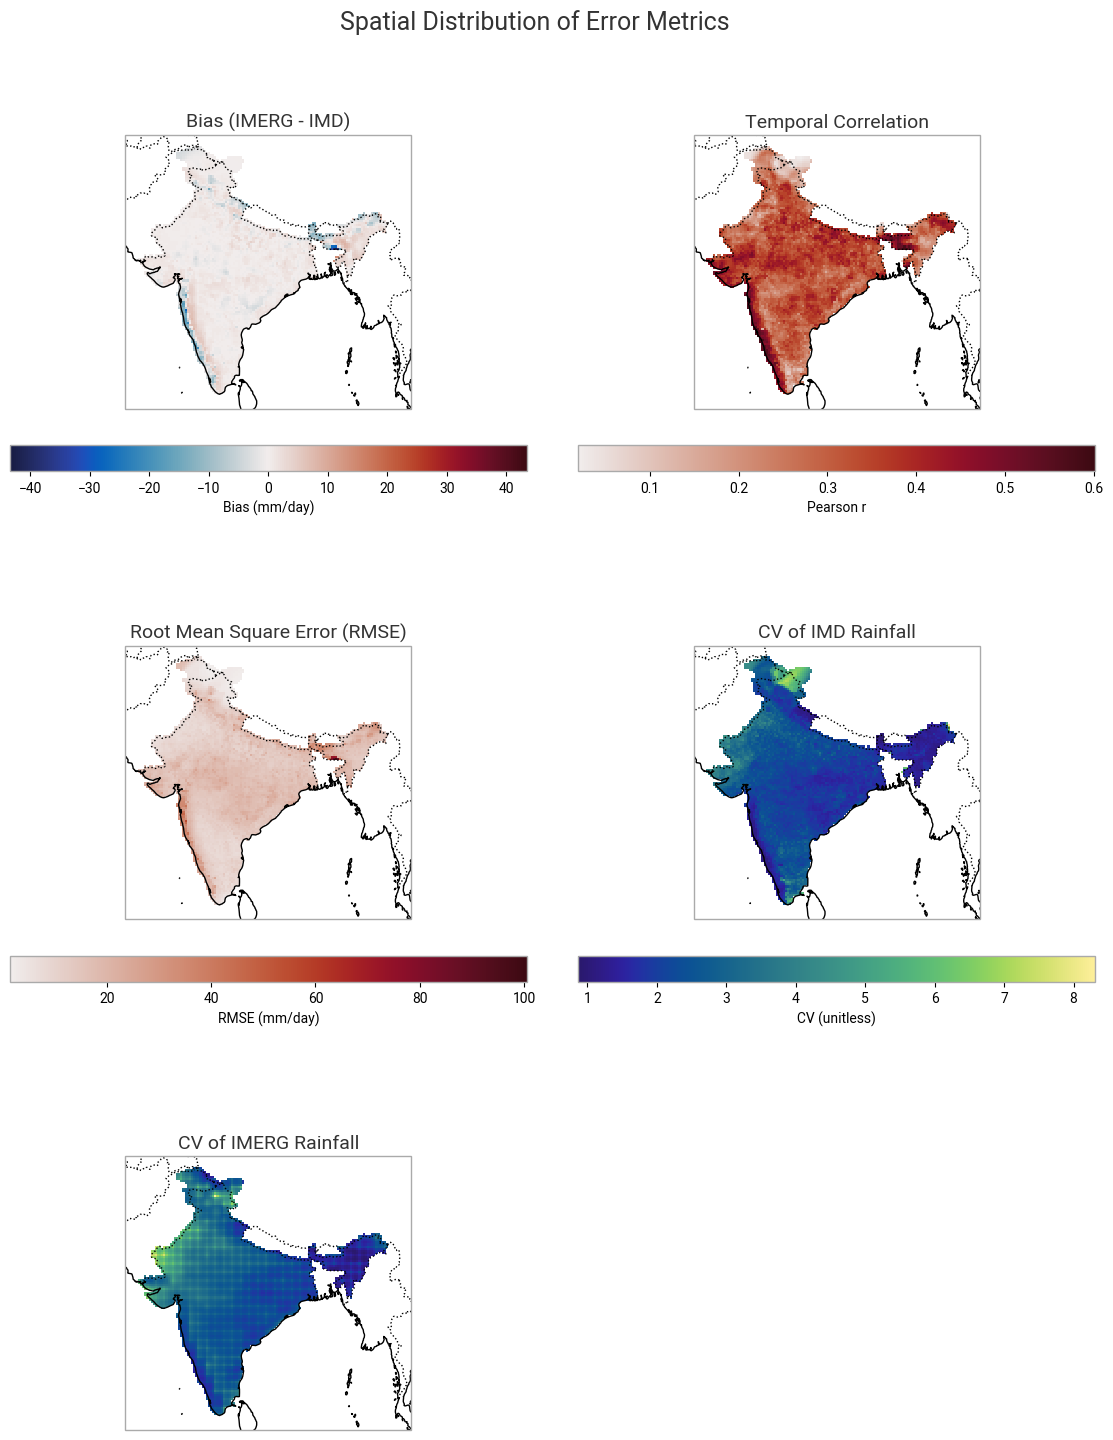

In [64]:

# Bias
bias = imerg_data.mean(dim='time') - imd_data.mean(dim='time')

# RMSE
rmse = np.sqrt(((imerg_data - imd_data)**2).mean(dim='time'))

# Correlation (using apply_ufunc for pixel-wise calculation)
def calculate_correlation(x, y):
    # Drop NaNs for this specific pixel's timeseries
    valid_indices = ~np.isnan(x) & ~np.isnan(y)
    x_valid, y_valid = x[valid_indices], y[valid_indices]
    if len(x_valid) < 2: # Need at least 2 points to correlate
        return np.nan
    return pearsonr(x_valid, y_valid)[0]


# fixed zero dim issue
correlation = xr.apply_ufunc(
    calculate_correlation, imd_data, imerg_data,
    input_core_dims=[['time'], ['time']], # Operates on the 'time' dimension
    output_core_dims=[[]],               # Expects a scalar (0D) output
    exclude_dims=set(('time',)),         # A safeguard to not broadcast 'time'
    dask="parallelized",                 # Use dask for parallel computation
    output_dtypes=[float],               # The output type is float
    vectorize=True                       # Vectorize the function for efficiency
)
correlation.name = "Correlation"

# Coefficient of Variation (CV)
cv_imd = imd_data.std(dim='time') / imd_data.mean(dim='time')
cv_imerg = imerg_data.std(dim='time') / imerg_data.mean(dim='time')

# --- Plotting ---
fig = plt.figure(figsize=(14, 18))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.1)
fig.suptitle('Spatial Distribution of Error Metrics', fontsize=18, y=0.95)

def create_map_subplot(fig, spec, data, title, cmap, cbar_label):
    ax = fig.add_subplot(spec, projection=ccrs.PlateCarree())
    data.plot(ax=ax, cmap=cmap, cbar_kwargs={'label': cbar_label, 'orientation': 'horizontal', 'pad': 0.1})
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.set_title(title, fontsize=14)
    return ax

create_map_subplot(fig, gs[0, 0], bias, 'Bias (IMERG - IMD)', cmocean.cm.balance, 'Bias (mm/day)')
create_map_subplot(fig, gs[0, 1], correlation, 'Temporal Correlation', cmocean.cm.amp, 'Pearson r')
create_map_subplot(fig, gs[1, 0], rmse, 'Root Mean Square Error (RMSE)', cmocean.cm.amp, 'RMSE (mm/day)')
create_map_subplot(fig, gs[1, 1], cv_imd, 'CV of IMD Rainfall', cmocean.cm.haline, 'CV (unitless)')
create_map_subplot(fig, gs[2, 0], cv_imerg, 'CV of IMERG Rainfall', cmocean.cm.haline, 'CV (unitless)')

# Remove the last empty subplot
fig.delaxes(fig.axes[-1])

plt.show()

Generating Rainfall Category Scatter plots (Figure 7)...


KeyError: "not all values found in index 'time'. Try setting the `method` keyword argument (example: method='nearest')."

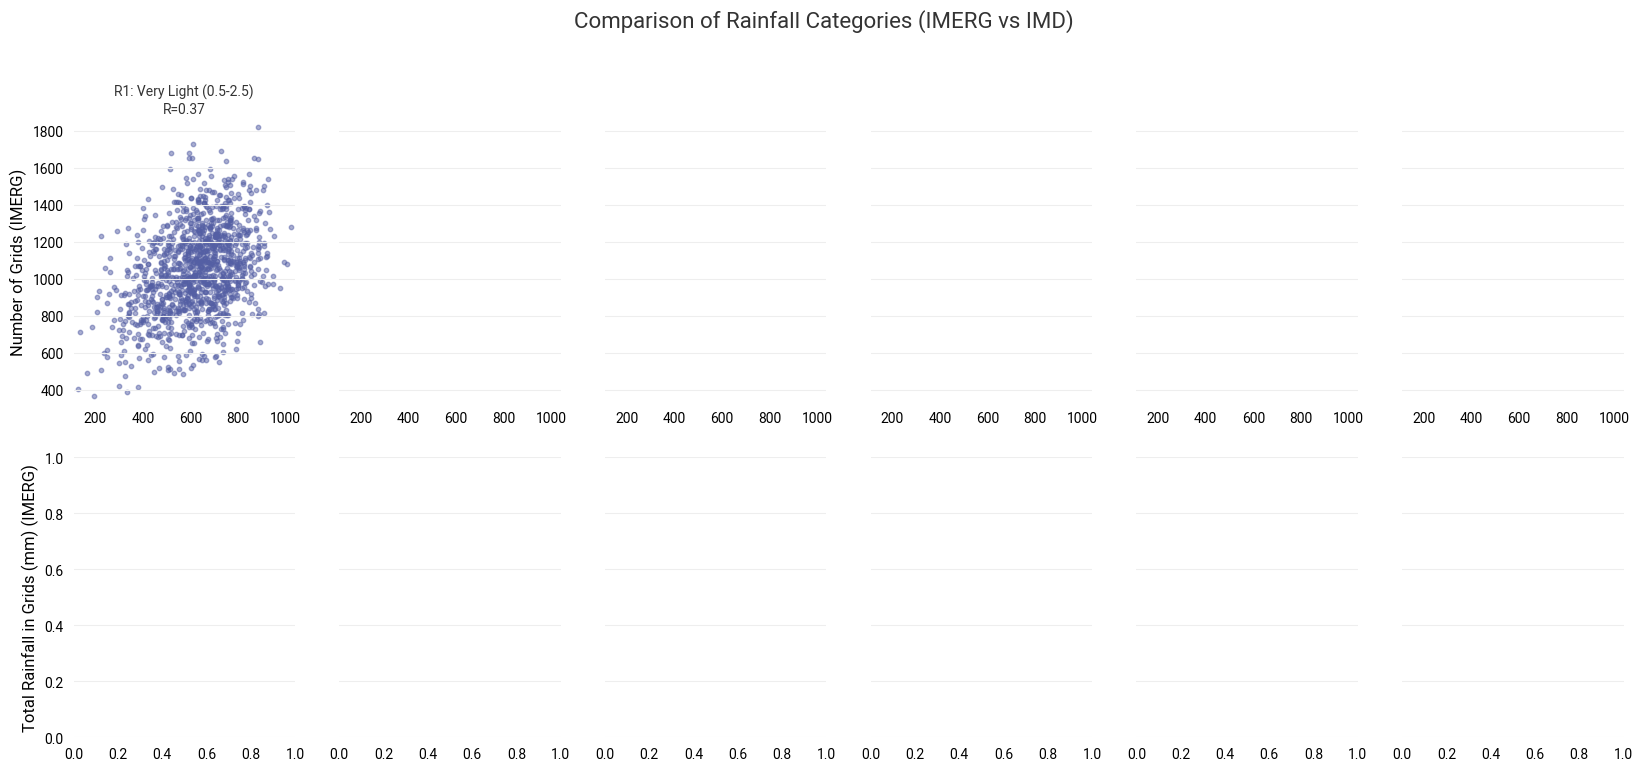

In [65]:
plot_rainfall_category_scatters(imd_proc, imerg_proc)